# ☕ Coffee Defect — Instance Segmentation YOLOv8s-seg + SAFT (REVISI v2)
**Platform:** Local VS Code · **Accelerator:** RTX 2060 (6GB VRAM)  
**Dataset:** defect-coffee-350g-1161 (Roboflow, polygon/instance segmentation)  
**Method:** SAFT (patch 640×640, overlap 0.5, gambar asli ikut training) → YOLOv8s-seg (imgsz=640) → Evaluasi → Inferensi SAHI + Instance Mask + SCA Grading  

**Ringkasan Revisi dari versi sebelumnya:**
- `patch_size` naik: 320×320 → **640×640**
- `overlap` naik: 0.2 → **0.5** (lebih banyak variasi posisi objek)
- `target_letterbox_size` naik: 320 → **640** (tetap 1:1 scale)
- Gambar asli **disalin ke folder train** (patch + asli = dataset lebih kaya)
- `imgsz` training naik: 320 → **640** (masih aman untuk RTX 2060 batch=8)
- Inferensi SAHI kini menampilkan **BBox + Instance Mask Segmentasi** sekaligus
- Bug SCA Grading diperbaiki: `severe insect` divisor 3 → **5** (sesuai standar SCA)
- Tahap 8B lama (duplikat + bug) **dihapus**, hanya pakai 8D sebagai sumber kebenaran tunggal

---


## TAHAP 1 — Setup Lingkungan & Instalasi Library

In [1]:
# ==============================================================================
# TAHAP 1A: INSTALASI LIBRARY
# ==============================================================================
# Jalankan sekali. Disarankan pakai virtual environment:
#   python -m venv venv
#   source venv/bin/activate        (Linux/Mac)
#   venv\Scripts\activate           (Windows)

import subprocess, sys

PACKAGES = [
    "ultralytics", "sahi", "roboflow", "shapely",
    "pyyaml", "opencv-python", "matplotlib", "tqdm"
]

for pkg in PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("[INFO] Semua library berhasil diinstall.")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


[INFO] Semua library berhasil diinstall.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# ==============================================================================
# TAHAP 1B: IMPORT & KONFIGURASI PATH LOKAL
# ==============================================================================
import os, cv2, math, yaml, shutil, time, threading, gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from pathlib import Path
from collections import Counter
from shapely.geometry import Polygon
from shapely.geometry import box as shapely_box
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import warnings
warnings.filterwarnings("ignore")

# ── Deteksi environment Jupyter vs script biasa ──
try:
    from IPython import get_ipython as _gip
    _IN_JUPYTER = _gip() is not None
except ImportError:
    _IN_JUPYTER = False

import matplotlib
if _IN_JUPYTER:
    matplotlib.use("inline")
    # %matplotlib inline  # uncomment jika di Jupyter
else:
    matplotlib.use("Agg")

# ── Deteksi GPU ──
import torch
print(f"PyTorch Version  : {torch.__version__}")
print(f"CUDA tersedia    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    DEVICE       = "0"
    DEVICE_INFER = "cuda:0"
else:
    print("⚠️  GPU tidak tersedia — berjalan di CPU (lebih lambat).")
    DEVICE       = "cpu"
    DEVICE_INFER = "cpu"

# ── Direktori kerja ──
HOME = os.getcwd()
os.makedirs(HOME, exist_ok=True)
print(f"[INFO] Working Directory : {HOME}")

# ── Checkpoint backup ──
BACKUP_DIR  = os.path.join(HOME, "sahi_checkpoint_backup")
BACKUP_LAST = os.path.join(BACKUP_DIR, "last.pt")
BACKUP_BEST = os.path.join(BACKUP_DIR, "best.pt")
os.makedirs(BACKUP_DIR, exist_ok=True)
print(f"[INFO] Checkpoint backup : {BACKUP_DIR}")

PyTorch Version  : 2.11.0+cu130
CUDA tersedia    : True
  GPU 0: NVIDIA GeForce RTX 2060
[INFO] Working Directory : /home/lab-ai/riki/baseline
[INFO] Checkpoint backup : /home/lab-ai/riki/baseline/sahi_checkpoint_backup


## TAHAP 2 — Download Dataset (Roboflow)

In [3]:
# ==============================================================================
# TAHAP 2: DOWNLOAD DATASET DARI ROBOFLOW
# ==============================================================================
from roboflow import Roboflow

DATASET_PATH = os.path.join(HOME, "defect-coffee-350g-1161-1")
YAML_PATH    = os.path.join(DATASET_PATH, "data.yaml")

if not os.path.exists(YAML_PATH):
    print("[INFO] Dataset belum ada, mendownload...")
    rf = Roboflow(api_key="XCt1ERaf9Ckc2RB189yo")
    project = rf.workspace("student-i41yd").project("defect-coffee-350g-1161")
    version = project.version(1)
    dataset = version.download("yolov8")
    DATASET_PATH = dataset.location
    YAML_PATH    = os.path.join(DATASET_PATH, "data.yaml")
else:
    print(f"[INFO] Dataset sudah ada, skip download → {DATASET_PATH}")

print(f"[INFO] Dataset path : {DATASET_PATH}")
print(f"[INFO] YAML path    : {YAML_PATH}")

[INFO] Dataset sudah ada, skip download → /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1
[INFO] Dataset path : /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1
[INFO] YAML path    : /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1/data.yaml


## TAHAP 3 — SAFT Slicing Module (REVISI v2)
> **Perubahan dari versi sebelumnya:**  
> - `patch_size` default: 320 → **640**  
> - `overlap` default: 0.2 → **0.5**  
> - `target_letterbox_size` default: 320 → **640** (tetap 1:1 scale)  
> - Filter threshold polygon tetap: `intersection.area / poly.area >= 0.2`

In [4]:
# ==============================================================================
# TAHAP 3: FUNGSI SAFT FILTER (POLYGON / INSTANCE SEGMENTATION) — REVISI v2
# ==============================================================================

def read_yolo_seg_label(label_path: str) -> list:
    """Baca file label YOLO segmentation.
    Format per baris: class_id x1 y1 x2 y2 ... (koordinat ternormalisasi 0-1)
    """
    labels = []
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                vals = line.strip().split()
                if vals:
                    labels.append([float(v) for v in vals])
    return labels


def write_yolo_seg_label(label_path: str, labels: list) -> None:
    """Tulis label YOLO segmentation ke file teks."""
    with open(label_path, "w") as f:
        for label in labels:
            row = [str(int(label[0]))] + [f"{v:.6f}" for v in label[1:]]
            f.write(" ".join(row) + "\n")


def letterbox_resize(image: np.ndarray,
                     target_size: tuple = (640, 640),   # REVISI: 320 → 640
                     color: tuple = (114, 114, 114)):
    """Resize gambar ke target_size dengan letterbox padding (jaga aspek rasio).
    Return: (padded_image, scale, pad_x, pad_y)
    """
    h, w = image.shape[:2]
    scale = min(target_size[0] / h, target_size[1] / w)
    nh, nw = int(h * scale), int(w * scale)
    resized = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
    top    = (target_size[0] - nh) // 2
    bottom =  target_size[0] - nh - top
    left   = (target_size[1] - nw) // 2
    right  =  target_size[1] - nw - left
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                cv2.BORDER_CONSTANT, value=color)
    return padded, scale, left, top


def slice_aided_fine_tune_dataset_seg(
    image: np.ndarray,
    labels: list,
    patch_size: tuple = (640, 640),             # REVISI: 320 → 640
    overlap: float = 0.5,                        # REVISI: 0.2 → 0.5
    target_letterbox_size: tuple = (640, 640)    # REVISI: 320 → 640 (tetap 1:1 scale)
):
    """
    Slice gambar menjadi patch-patch, filter polygon dengan syarat:
    luas irisan / luas polygon asli >= 0.2  (threshold SAHI).

    Return: (list_patch_image, list_patch_labels)
    """
    H, W = image.shape[:2]
    step_x = max(1, int(patch_size[1] * (1 - overlap)))
    step_y = max(1, int(patch_size[0] * (1 - overlap)))

    image_patches: list          = []
    updated_patches_labels: list = []
    patch_index = 0

    for y1_p in range(0, H - 1, step_y):
        for x1_p in range(0, W - 1, step_x):
            x2_p = min(x1_p + patch_size[1], W - 1)
            y2_p = min(y1_p + patch_size[0], H - 1)
            patch = image[y1_p:y2_p, x1_p:x2_p]
            patch_index += 1

            patch_box = shapely_box(x1_p, y1_p, x2_p, y2_p)
            patch_polygons, patch_classes = [], []

            for label in labels:
                class_id = int(label[0])
                coords   = label[1:]
                if len(coords) < 6 or len(coords) % 2 != 0:
                    continue
                abs_pts = [(coords[i] * W, coords[i + 1] * H)
                           for i in range(0, len(coords), 2)]
                poly = Polygon(abs_pts)
                if not poly.is_valid:
                    poly = poly.buffer(0)
                if poly.is_empty or poly.area == 0:
                    continue
                if not poly.intersects(patch_box):
                    continue
                intersection = poly.intersection(patch_box)
                if intersection.is_empty:
                    continue
                if intersection.area / poly.area < 0.2:   # threshold SAHI
                    continue

                # Ekstrak geometri hasil interseksi
                if intersection.geom_type == "Polygon":
                    polys = [intersection]
                elif intersection.geom_type == "MultiPolygon":
                    polys = list(intersection.geoms)
                elif intersection.geom_type == "GeometryCollection":
                    polys = [g for g in intersection.geoms if g.geom_type == "Polygon"]
                else:
                    polys = []

                for p in polys:
                    shifted = [(x - x1_p, y - y1_p) for x, y in p.exterior.coords]
                    patch_polygons.append(shifted)
                    patch_classes.append(class_id)

            if not patch_polygons:
                continue  # skip patch tanpa objek

            lb_patch, scale, pad_x, pad_y = letterbox_resize(
                patch, target_size=target_letterbox_size
            )
            ph, pw = patch.shape[:2]
            lbH, lbW = target_letterbox_size

            yolo_labels = []
            for cls_id, poly_coords in zip(patch_classes, patch_polygons):
                norm_poly = []
                for x, y in poly_coords:
                    # Terapkan scale + padding letterbox
                    nx = max(0.0, min(1.0, (x * scale + pad_x) / lbW))
                    ny = max(0.0, min(1.0, (y * scale + pad_y) / lbH))
                    norm_poly.extend([nx, ny])
                if len(norm_poly) >= 6:
                    yolo_labels.append([cls_id] + norm_poly)

            if yolo_labels:
                image_patches.append((patch_index, lb_patch))
                updated_patches_labels.append(yolo_labels)

    return image_patches, updated_patches_labels


def SAHI_Fine_Tune_Process_Seg(
    images_dir: str,
    labels_dir: str,
    output_dir: str,
    patch_size:  tuple = (640, 640),    # REVISI: 320 → 640
    overlap:     float = 0.5,            # REVISI: 0.2 → 0.5
    target_size: tuple = (640, 640),    # REVISI: 320 → 640
    copy_originals: bool = True          # BARU: salin gambar asli ke folder train
):
    """
    Jalankan SAFT slicing pada seluruh gambar dalam images_dir.
    Jika copy_originals=True, gambar asli juga disalin ke output_dir
    sehingga dataset train = patch SAHI + gambar asli.
    """
    out_img_dir = os.path.join(output_dir, "images")
    out_lbl_dir = os.path.join(output_dir, "labels")
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    image_files = [f for f in os.listdir(images_dir)
                   if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    for img_file in tqdm(image_files, desc="SAFT Slicing"):
        img_path   = os.path.join(images_dir, img_file)
        stem       = os.path.splitext(img_file)[0]
        label_path = os.path.join(labels_dir, stem + ".txt")

        image  = cv2.imread(img_path)
        if image is None:
            print(f"[WARN] Gagal membaca: {img_path}")
            continue

        labels = read_yolo_seg_label(label_path)
        if not labels:
            # Tidak ada label → lewati slicing, tapi tetap salin aslinya
            if copy_originals:
                shutil.copy2(img_path,   os.path.join(out_img_dir, img_file))
                if os.path.exists(label_path):
                    shutil.copy2(label_path, os.path.join(out_lbl_dir, stem + ".txt"))
            continue

        image_patches, patch_labels = slice_aided_fine_tune_dataset_seg(
            image, labels, patch_size, overlap, target_size
        )

        for (pidx, patch_img), p_lbls in zip(image_patches, patch_labels):
            fname = f"{stem}_patch{pidx:04d}_saft.jpg"
            cv2.imwrite(os.path.join(out_img_dir, fname), patch_img)
            write_yolo_seg_label(os.path.join(out_lbl_dir,
                                              fname.replace(".jpg", ".txt")), p_lbls)

        # ── BARU: Salin gambar & label ASLI ke folder train ──
        # Ini mengikuti strategi dari coffee_defect_detection__2026duplicate.ipynb
        # sehingga model "melihat" konteks gambar penuh, tidak hanya patch kecil
        if copy_originals:
            shutil.copy2(img_path,   os.path.join(out_img_dir, img_file))
            shutil.copy2(label_path, os.path.join(out_lbl_dir, stem + ".txt"))

    print(f"[INFO] Selesai. Total gambar train:")
    n = len([f for f in os.listdir(out_img_dir) if f.endswith(".jpg")])
    print(f"  → {n} file (patch + gambar asli)")

## TAHAP 4 — Eksekusi SAFT & Buat data.yaml Baru

In [5]:
# ==============================================================================
# TAHAP 4A: JALANKAN SAFT SLICING PADA DATA TRAIN (REVISI v2)
# ==============================================================================
SAHI_TRAIN_DIR = os.path.join(HOME, "datasets", "sahi_filter_seg_v2", "train")

print("[INFO] Memulai proses slicing SAFT v2 pada data Train ...")
print("  patch_size  = 640×640")
print("  overlap     = 0.5")
print("  target_size = 640×640  (1:1 scale)")
print("  copy_originals = True  (gambar asli ikut disalin)")
print()

SAHI_Fine_Tune_Process_Seg(
    images_dir     = os.path.join(DATASET_PATH, "train", "images"),
    labels_dir     = os.path.join(DATASET_PATH, "train", "labels"),
    output_dir     = SAHI_TRAIN_DIR,
    patch_size     = (640, 640),
    overlap        = 0.5,
    target_size    = (640, 640),
    copy_originals = True          # BARU: gambar asli ikut masuk training
)

[INFO] Memulai proses slicing SAFT v2 pada data Train ...
  patch_size  = 640×640
  overlap     = 0.5
  target_size = 640×640  (1:1 scale)
  copy_originals = True  (gambar asli ikut disalin)



SAFT Slicing: 100%|██████████| 809/809 [03:15<00:00,  4.14it/s]

[INFO] Selesai. Total gambar train:
  → 22766 file (patch + gambar asli)


In [6]:
# ==============================================================================
# TAHAP 4B: HITUNG JUMLAH PATCH & BUAT data.yaml BARU
# ==============================================================================
n_patch_img = len([f for f in os.listdir(os.path.join(SAHI_TRAIN_DIR, "images"))
                   if f.endswith(".jpg")])
print(f"[INFO] Total gambar train setelah SAFT v2: {n_patch_img}")

with open(YAML_PATH, "r") as f:
    data_yaml = yaml.safe_load(f)

NEW_YAML_PATH = os.path.join(HOME, "datasets", "sahi_filter_seg_v2", "data.yaml")

data_yaml["train"] = str(Path(SAHI_TRAIN_DIR, "images").resolve())
data_yaml["val"]   = str(Path(DATASET_PATH, "valid", "images").resolve())
data_yaml["test"]  = str(Path(DATASET_PATH, "test",  "images").resolve())

os.makedirs(os.path.dirname(NEW_YAML_PATH), exist_ok=True)
with open(NEW_YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"[INFO] data.yaml baru berhasil dibuat: {NEW_YAML_PATH}")
print()
print("Isi data.yaml:")
print(yaml.dump(data_yaml))

[INFO] Total gambar train setelah SAFT v2: 22766
[INFO] data.yaml baru berhasil dibuat: /home/lab-ai/riki/baseline/datasets/sahi_filter_seg_v2/data.yaml

Isi data.yaml:
names:
- broken
- cherry pod
- floater
- foreign material
- full black
- full sour
- fungus
- hull
- immature
- parchment
- partial black
- partial sour
- severe insect
- shell
- slight insect
- withered
nc: 16
roboflow:
  license: CC BY 4.0
  project: defect-coffee-350g-1161
  url: https://universe.roboflow.com/student-i41yd/defect-coffee-350g-1161/dataset/1
  version: 1
  workspace: student-i41yd
test: /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1/test/images
train: /home/lab-ai/riki/baseline/datasets/sahi_filter_seg_v2/train/images
val: /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1/valid/images



## Recovery Cell — Jalankan jika kernel di-restart setelah training

In [7]:
# ==============================================================================
# RECOVERY CELL — Jalankan ini jika kernel di-restart setelah training selesai
# ==============================================================================
import os, glob, torch, platform
from ultralytics import YOLO

HOME         = os.getcwd()
OUTPUT_DIR   = os.path.join(HOME, "sahi_coffee_seg_project_v2")
DATASET_PATH = glob.glob(os.path.join(HOME, "defect-coffee*"))[0]
YAML_PATH    = os.path.join(DATASET_PATH, "data.yaml")
NEW_YAML_PATH = os.path.join(HOME, "datasets", "sahi_filter_seg_v2", "data.yaml")

train_dir       = os.path.join(OUTPUT_DIR, "yolov8s_seg_saft_v2")
BEST_MODEL_PATH = os.path.join(train_dir, "weights", "best.pt")
BACKUP_DIR      = os.path.join(HOME, "sahi_checkpoint_backup")

if torch.cuda.is_available():
    DEVICE       = "0"
    DEVICE_INFER = "cuda:0"
else:
    DEVICE       = "cpu"
    DEVICE_INFER = "cpu"

NUM_WORKERS = 0 if platform.system() == "Windows" else 2

print(f"[INFO] Dataset     : {DATASET_PATH}")
print(f"[INFO] YAML baru   : {NEW_YAML_PATH}")
print(f"[INFO] Best model  : {BEST_MODEL_PATH}")
print(f"[INFO] Model exist : {'✅ OK' if os.path.exists(BEST_MODEL_PATH) else '❌ Tidak ditemukan'}")

[INFO] Dataset     : /home/lab-ai/riki/baseline/defect-coffee-350g-cp-1
[INFO] YAML baru   : /home/lab-ai/riki/baseline/datasets/sahi_filter_seg_v2/data.yaml
[INFO] Best model  : /home/lab-ai/riki/baseline/sahi_coffee_seg_project_v2/yolov8s_seg_saft_v2/weights/best.pt
[INFO] Model exist : ❌ Tidak ditemukan


## TAHAP 5 — Training YOLOv8s-seg (REVISI v2)
> **imgsz=640** — masih aman untuk RTX 2060 6GB VRAM dengan `batch=8`.  
> Jika muncul `CUDA out of memory`, turunkan `batch` ke `4`.

In [13]:
# ==============================================================================
# TAHAP 5: TRAINING YOLOv8s-SEG (LOCAL — RESUME OTOMATIS) — REVISI v2
# ==============================================================================
import platform, shutil, time, threading
from ultralytics import YOLO

HOME        = os.getcwd()
OUTPUT_DIR  = os.path.join(HOME, "sahi_coffee_seg_project_v2")
BACKUP_DIR  = os.path.join(HOME, "sahi_checkpoint_backup")
BACKUP_LAST = os.path.join(BACKUP_DIR, "last.pt")
BACKUP_BEST = os.path.join(BACKUP_DIR, "best.pt")

TRAIN_DIR   = os.path.join(OUTPUT_DIR, "yolov8s_seg_saft_v2")
WEIGHTS_DIR = os.path.join(TRAIN_DIR, "weights")
LAST_PT     = os.path.join(WEIGHTS_DIR, "last.pt")
BEST_PT     = os.path.join(WEIGHTS_DIR, "best.pt")
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# ── Restore checkpoint dari backup jika perlu ──
if not os.path.exists(LAST_PT) and os.path.exists(BACKUP_LAST):
    print("[INFO] Merestore checkpoint dari backup...")
    shutil.copy2(BACKUP_LAST, LAST_PT)
    if os.path.exists(BACKUP_BEST):
        shutil.copy2(BACKUP_BEST, BEST_PT)
    size_mb = os.path.getsize(LAST_PT) / 1_048_576
    print(f"[INFO] ✅ Restore berhasil. last.pt ({size_mb:.1f} MB)")
elif os.path.exists(LAST_PT):
    print("[INFO] Checkpoint sudah ada → siap resume.")
else:
    print("[INFO] Tidak ada checkpoint → training dari awal.")

# ── Auto-backup background setiap 30 menit ──
_stop_backup = threading.Event()

def _auto_backup_worker(interval_seconds=1800):
    while not _stop_backup.wait(interval_seconds):
        ts = time.strftime("%H:%M:%S")
        for src, dst, fname in [(LAST_PT, BACKUP_LAST, "last.pt"),
                                (BEST_PT,  BACKUP_BEST, "best.pt")]:
            if os.path.exists(src):
                try:
                    shutil.copy2(src, dst)
                    print(f"[AUTO-BACKUP {ts}] ✅ {fname} → {BACKUP_DIR}")
                except Exception as e:
                    print(f"[AUTO-BACKUP {ts}] Gagal: {fname} — {e}")

backup_thread = threading.Thread(target=_auto_backup_worker, args=(1800,), daemon=True)
backup_thread.start()
print("[INFO] Background auto-backup aktif (setiap 30 menit)")

# ── Sesuaikan workers ──
NUM_WORKERS = 0 if platform.system() == "Windows" else 2

# ── Training / Resume ──
if os.path.exists(LAST_PT):
    print("[INFO] ✅ RESUME dari epoch terakhir")
    model_seg = YOLO(LAST_PT)
    results = model_seg.train(
        resume  = True,
        device  = DEVICE,
        workers = NUM_WORKERS,
        verbose = True
    )
else:
    print("[INFO] Mulai training baru (epoch 1)")
    model_seg = YOLO("yolov8s-seg.pt")
    results = model_seg.train(
        data      = NEW_YAML_PATH,
        epochs    = 60,
        imgsz     = 640,     # REVISI: 320 → 640 (lebih baik untuk objek kecil)
        batch     = 4,       # Aman untuk RTX 2060 6GB; turunkan ke 4 jika OOM
        device    = DEVICE,
        workers   = NUM_WORKERS,
        patience  = 20,
        optimizer = "AdamW",
        lr0       = 1e-3,
        project   = OUTPUT_DIR,
        name      = "yolov8s_seg_saft_v2",
        exist_ok  = True,
        amp       = True,    # Mixed precision: hemat VRAM ~30%
        verbose   = True
    )

# ── Final backup ──
_stop_backup.set()
BEST_MODEL_PATH = BEST_PT
print(f"\n[INFO] Training selesai. Model terbaik: {BEST_MODEL_PATH}")

for src, dst, fname in [(LAST_PT, BACKUP_LAST, "last.pt"),
                        (BEST_PT,  BACKUP_BEST, "best.pt")]:
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1_048_576
        print(f"[FINAL BACKUP] ✅ {fname} ({size_mb:.1f} MB) → {BACKUP_DIR}")

[INFO] Tidak ada checkpoint → training dari awal.
[INFO] Background auto-backup aktif (setiap 30 menit)
[INFO] Mulai training baru (epoch 1)
New https://pypi.org/project/ultralytics/8.4.78 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.48 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5729MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/lab-ai/riki/baseline/datasets/sahi_filter_seg_v2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=

In [14]:
# ==============================================================================
# BACKUP MANUAL — Jalankan kapan saja
# ==============================================================================
ts = time.strftime("%Y-%m-%d %H:%M:%S")
print(f"[BACKUP MANUAL] {ts}")

for fname in ["last.pt", "best.pt"]:
    src = os.path.join(TRAIN_DIR, "weights", fname)
    dst = os.path.join(BACKUP_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1_048_576
        print(f"  ✅ {fname} → {BACKUP_DIR}  ({size_mb:.1f} MB)")
    else:
        print(f"  ⚠️  {fname} belum ada, dilewati.")

print("\n[INFO] Backup selesai.")

[BACKUP MANUAL] 2026-06-27 02:53:47
  ✅ last.pt → /home/lab-ai/riki/baseline/sahi_checkpoint_backup  (22.8 MB)
  ✅ best.pt → /home/lab-ai/riki/baseline/sahi_checkpoint_backup  (22.8 MB)

[INFO] Backup selesai.


## TAHAP 6 — Evaluasi Model (mAP, IoU, Confusion Matrix)

Ultralytics 8.4.48 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5729MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,785,792 parameters, 0 gradients, 40.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 31.6±40.4 MB/s, size: 319.2 KB)
val: Scanning /home/lab-ai/riki/baseline/defect-coffee-350g-1161-1/test/labels.cache... 115 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 68.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.5s/it 28.1s1.4sss
                   all        115      10535      0.416      0.456      0.373      0.282      0.415       0.44      0.363      0.175
                broken         87       1322      0.376       0.29      0.193       0.15      0.383      0.281       0.19     0.0974
            cherry pod         26         41      0.519      0.659      0.522      0.432      0.501       0.61      0.504    

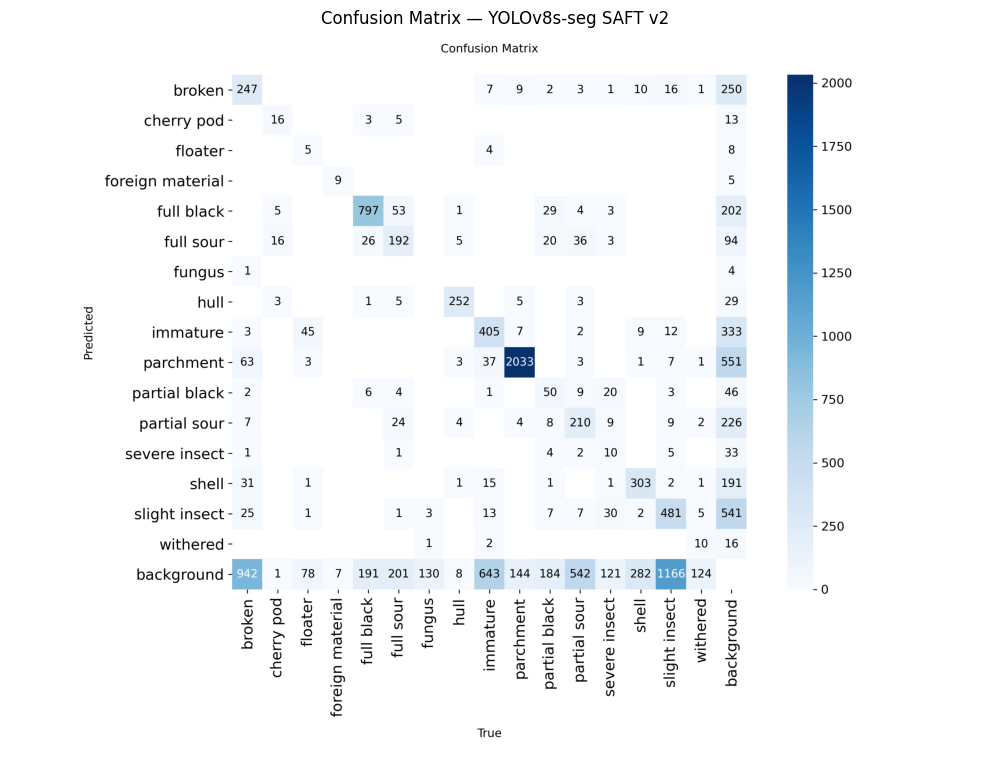

[INFO] Confusion matrix disimpan: /home/lab-ai/riki/baseline/runs/segment/val-4/confusion_matrix_preview.png


In [15]:
# ==============================================================================
# TAHAP 6A: METRIK EVALUASI — MASK SEGMENTASI
# ==============================================================================
best_model = YOLO(BEST_MODEL_PATH)

metrics = best_model.val(
    data    = NEW_YAML_PATH,
    split   = "test",
    device  = DEVICE,
    workers = NUM_WORKERS
)

seg = metrics.seg
print("\n" + "=" * 50)
print("HASIL METRIK EVALUASI — MASK (SEGMENTASI)")
print("=" * 50)
print(f"mAP@0.50       : {seg.map50:.4f}")
print(f"mAP@0.50:0.95  : {seg.map:.4f}")
print(f"Precision      : {seg.mp:.4f}")
print(f"Recall         : {seg.mr:.4f}")

cm_path = os.path.join(str(metrics.save_dir), "confusion_matrix.png")
if os.path.exists(cm_path):
    cm_img = cv2.cvtColor(cv2.imread(cm_path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_img)
    plt.title("Confusion Matrix — YOLOv8s-seg SAFT v2")
    plt.axis("off")
    plt.tight_layout()
    cm_out = os.path.join(str(metrics.save_dir), "confusion_matrix_preview.png")
    plt.savefig(cm_out, dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"[INFO] Confusion matrix disimpan: {cm_out}")


── results.png ──


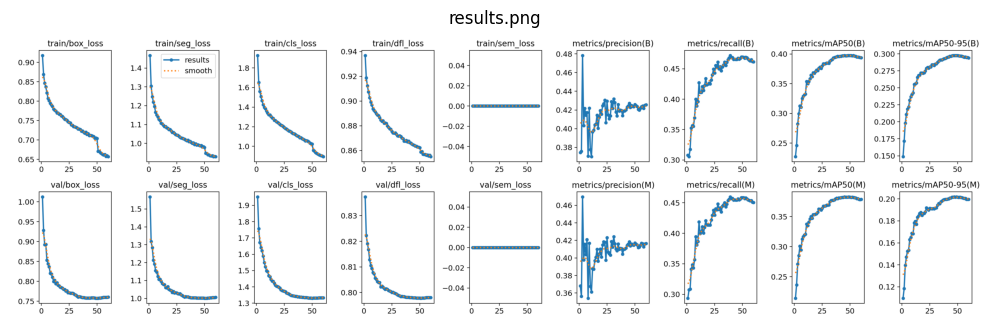

[WARNING] F1_curve.png tidak ditemukan.
[WARNING] P_curve.png tidak ditemukan.
[WARNING] R_curve.png tidak ditemukan.
[WARNING] PR_curve.png tidak ditemukan.


In [16]:
# ==============================================================================
# TAHAP 6B: KURVA TRAINING
# ==============================================================================
train_dir = os.path.join(HOME, "sahi_coffee_seg_project_v2", "yolov8s_seg_saft_v2")

for curve_file in ["results.png", "F1_curve.png", "P_curve.png",
                   "R_curve.png", "PR_curve.png"]:
    curve_path = os.path.join(train_dir, curve_file)
    if os.path.exists(curve_path):
        print(f"\n── {curve_file} ──")
        img_c = cv2.cvtColor(cv2.imread(curve_path), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(img_c)
        plt.title(curve_file)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(train_dir, f"preview_{curve_file}"),
                    dpi=100, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        print(f"[WARNING] {curve_file} tidak ditemukan.")

## TAHAP 7 — Visualisasi Prediksi SAHI + Instance Mask Segmentasi
> **REVISI:** Versi sebelumnya hanya menampilkan Bounding Box.  
> Versi ini menampilkan **BBox + Instance Mask** sekaligus menggunakan inferensi segmentasi penuh (bukan `task='detect'`).

[INFO] Memproses visualisasi SAHI + Mask untuk 3 gambar sampel...
[1/3] DSCF1098_JPG.rf.506f6ba1e9532703d4e19370895ad036.jpg
[2/3] DSCF1111_JPG.rf.19ff2b9eef889d9314deee4e8ca9b747.jpg
[3/3] DSCF1120_JPG.rf.a2812995e8ddb6a68ad535b1172995ea.jpg

[INFO] Gambar tersimpan di: /home/lab-ai/riki/baseline/sahi_vis_output_v2
[INFO] Grid preview disimpan: /home/lab-ai/riki/baseline/sahi_seg_native_preview.png


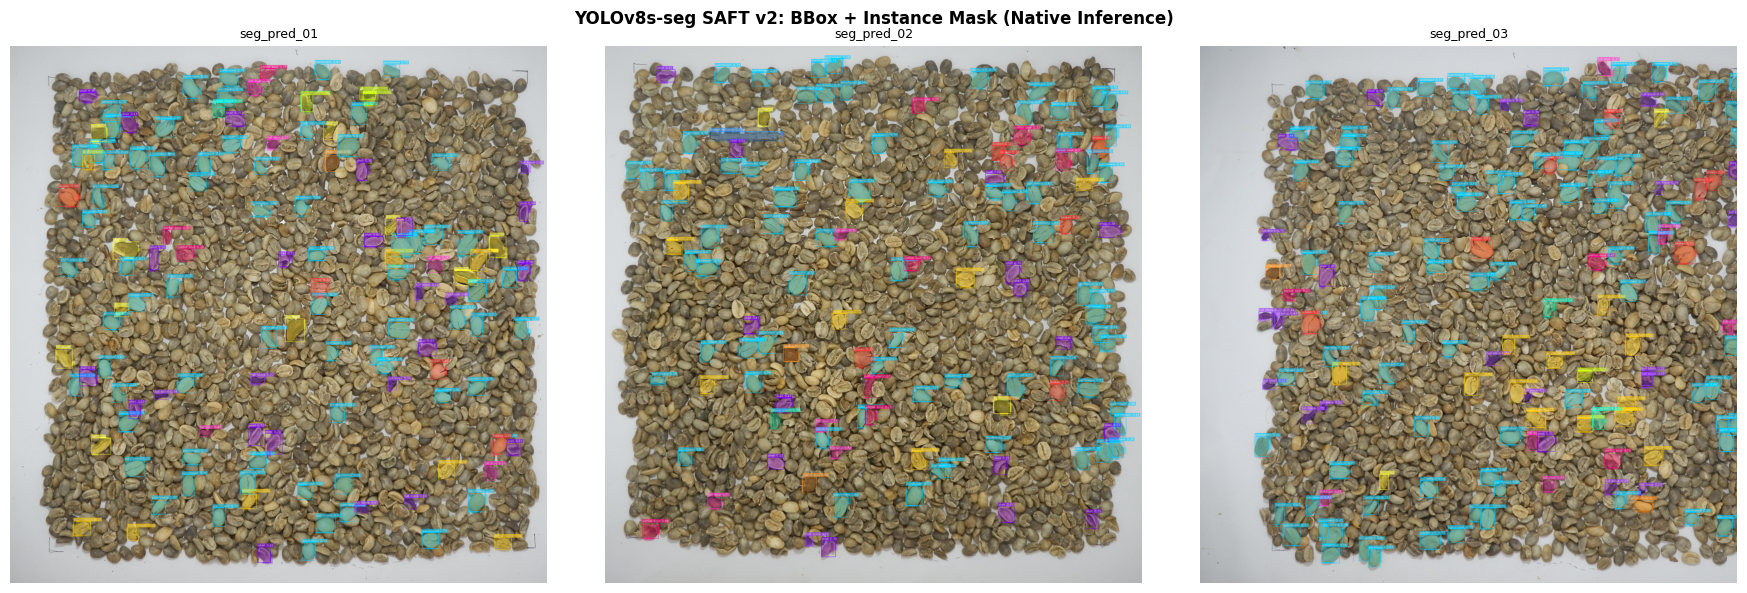

In [17]:
# ==============================================================================
# TAHAP 7: VISUALISASI SAHI + BBOX + INSTANCE MASK SEGMENTASI
# ==============================================================================
gc.collect()
torch.cuda.empty_cache()

HOME       = os.getcwd()
save_dir   = os.path.join(HOME, "sahi_vis_output_v2")
os.makedirs(save_dir, exist_ok=True)

# Ambil 3 sampel gambar dari data test
images = sorted(Path(os.path.join(DATASET_PATH, "test", "images")).glob("*.jpg"))[:3]
print(f"[INFO] Memproses visualisasi SAHI + Mask untuk {len(images)} gambar sampel...")

# Warna per kelas (RGB) — sesuaikan jika jumlah kelas berbeda
CLASS_COLORS = [
    (255,  56,  56), (255, 157,  51), ( 51, 255, 114), ( 51, 153, 255),
    (153,  51, 255), (255,  51, 204), ( 51, 255, 255), (255, 255,  51),
    (255, 128,   0), (  0, 204, 255), (204, 255,   0), (255,   0, 128),
    (  0, 255, 204), (128,   0, 255), (255, 204,   0), (  0, 128, 255),
]

def get_color(class_id: int):
    return CLASS_COLORS[class_id % len(CLASS_COLORS)]


def draw_bbox_and_mask(img_bgr: np.ndarray, results) -> np.ndarray:
    """
    Gambar BBox + Instance Mask dari hasil YOLO segmentasi.
    results: output dari model(img_path)[0]  — YOLO native results
    """
    vis = img_bgr.copy()
    overlay = img_bgr.copy()
    H, W = vis.shape[:2]

    if results.masks is None:
        print("[WARN] Tidak ada mask yang terdeteksi.")
        return vis

    for i, (box, mask_xy) in enumerate(zip(results.boxes, results.masks.xy)):
        cls_id   = int(box.cls.item())
        conf     = float(box.conf.item())
        color_rgb = get_color(cls_id)
        color_bgr = color_rgb[::-1]  # OpenCV pakai BGR

        # ── Gambar Instance Mask (polygon terisi, semi-transparan) ──
        if len(mask_xy) > 0:
            pts = mask_xy.astype(np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(overlay, [pts], color_bgr)

        # ── Gambar Bounding Box ──
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(vis, (x1, y1), (x2, y2), color_bgr, 2)

        # ── Label teks: nama kelas + confidence ──
        class_names = results.names
        label = f"{class_names[cls_id]} {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(vis, (x1, y1 - th - 6), (x1 + tw + 4, y1), color_bgr, -1)
        cv2.putText(vis, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    # Blend mask overlay (alpha=0.35)
    vis = cv2.addWeighted(overlay, 0.35, vis, 0.65, 0)
    return vis


# ── Load model dalam mode segmentasi penuh (BUKAN 'detect') ──
seg_model = YOLO(BEST_MODEL_PATH)
# Tidak menggunakan overrides['task']='detect' — biarkan model mengeluarkan mask

saved_paths = []
for idx, img_path in enumerate(images):
    print(f"[{idx+1}/{len(images)}] {img_path.name}")
    img_bgr = cv2.imread(str(img_path))

    with torch.no_grad():
        results = seg_model(str(img_path), conf=0.25, device=DEVICE_INFER, verbose=False)

    vis = draw_bbox_and_mask(img_bgr, results[0])
    out_path = os.path.join(save_dir, f"seg_pred_{idx+1:02d}.jpg")
    cv2.imwrite(out_path, vis)
    saved_paths.append(out_path)

    del results, img_bgr, vis
    gc.collect()

print(f"\n[INFO] Gambar tersimpan di: {save_dir}")

# ── Grid visualisasi ──
cols = len(saved_paths)
fig, axes = plt.subplots(1, cols, figsize=(6 * cols, 6), dpi=100)
if cols == 1:
    axes = [axes]

for i, path in enumerate(saved_paths):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(Path(path).stem, fontsize=9)
    axes[i].axis("off")
    del img

plt.suptitle("YOLOv8s-seg SAFT v2: BBox + Instance Mask (Native Inference)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
final_path = os.path.join(HOME, "sahi_seg_native_preview.png")
plt.savefig(final_path, dpi=100, bbox_inches="tight")
plt.close()
gc.collect()
print(f"[INFO] Grid preview disimpan: {final_path}")

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=final_path, width=900))
except Exception:
    pass

## TAHAP 8 — Inferensi SAHI (Sliced Prediction) + Instance Mask + SCA Grading
> **REVISI:**  
> - Tahap 8A–8B lama (duplikat + bug `severe insect` divisor=3) **dihapus total**  
> - Inferensi sekarang menggunakan YOLO native untuk menghasilkan **mask segmentasi**,  
>   digabung dengan slicing SAHI secara manual (slice → prediksi per patch → stitch)  
> - SCA Grading hanya ada **satu versi** (Tahap 8D) — `severe insect` divisor = **5** (benar)

In [18]:
# ==============================================================================
# TAHAP 8A: SETUP MODEL & PILIH GAMBAR TEST
# ==============================================================================
# Catatan arsitektur:
# SAHI AutoDetectionModel tidak support mask output secara native di semua versi.
# Solusi: kita lakukan slicing MANUAL menggunakan YOLO native (mendukung mask penuh),
# lalu gabungkan deteksi dari semua slice ke koordinat gambar asli.

seg_model_infer = YOLO(BEST_MODEL_PATH)
# Mode: segmentasi penuh — JANGAN override ke 'detect'

test_imgs = sorted(Path(os.path.join(DATASET_PATH, "test", "images")).glob("*.jpg"))
assert len(test_imgs) > 0, "Tidak ada gambar di folder test!"
TEST_IMAGE_PATH = str(test_imgs[0])
print(f"[INFO] Gambar test: {TEST_IMAGE_PATH}")

[INFO] Gambar test: /home/lab-ai/riki/baseline/defect-coffee-350g-cp-1/test/images/DSCF1098_JPG.rf.506f6ba1e9532703d4e19370895ad036.jpg


[INFO] Menjalankan SAHI Sliced Prediction + Instance Mask Segmentasi...
  [SAHI] Total slice: 36
[INFO] Hasil disimpan: /home/lab-ai/riki/baseline/sahi_filter_results_v2/sahi_seg_result.jpg


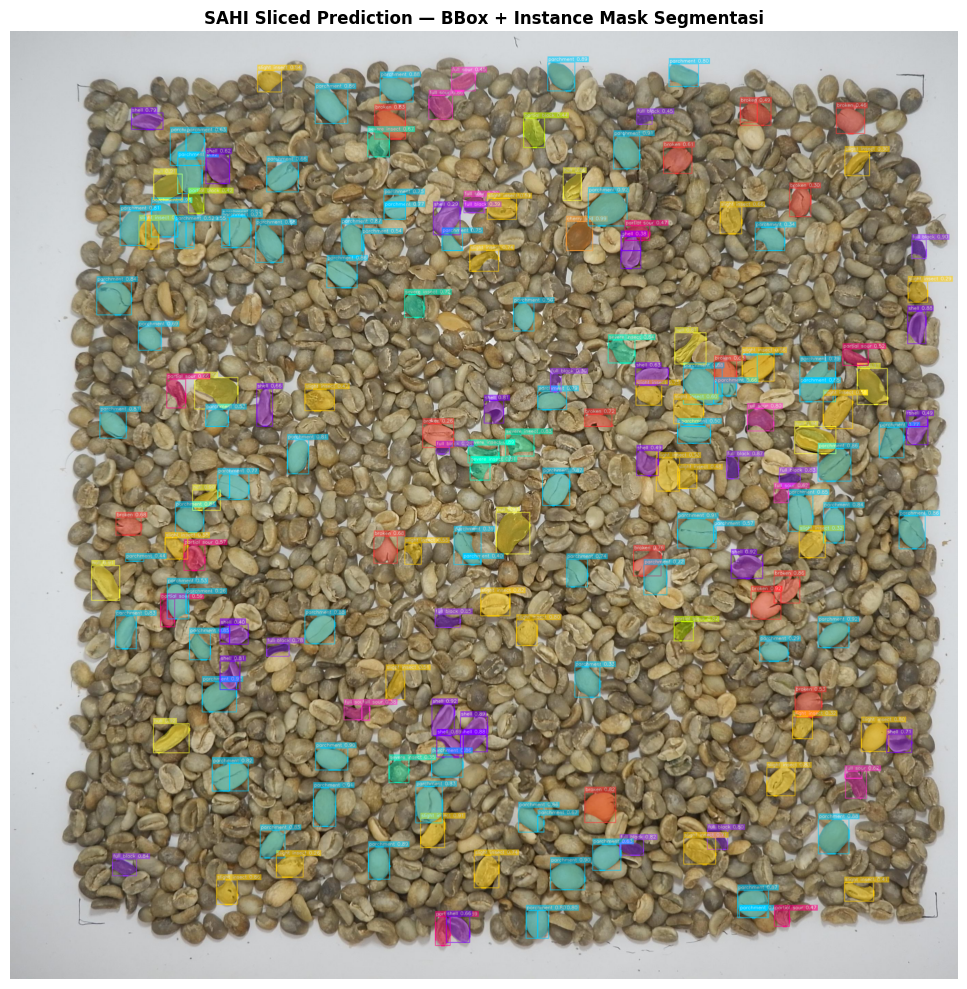


[INFO] Total objek terdeteksi: 197


In [19]:
# ==============================================================================
# TAHAP 8B: SAHI MANUAL SLICING + YOLO SEG INFERENCE + STITCH
# ==============================================================================
# Strategi:
# 1. Slice gambar asli menjadi patch 640×640 dengan overlap 0.2
# 2. Prediksi setiap patch menggunakan YOLO segmentasi
# 3. Konversi koordinat bbox & mask dari ruang patch → ruang gambar asli
# 4. Gabungkan semua deteksi + NMS untuk menghilangkan duplikat

from collections import defaultdict

SLICE_H   = 640
SLICE_W   = 640
OVERLAP   = 0.2
CONF_THR  = 0.25
NMS_IOU   = 0.5

def slice_image_for_infer(img: np.ndarray, slice_h: int, slice_w: int, overlap: float):
    """Generate (patch, x_offset, y_offset) dari gambar asli."""
    H, W = img.shape[:2]
    step_x = max(1, int(slice_w * (1 - overlap)))
    step_y = max(1, int(slice_h * (1 - overlap)))
    slices = []
    for y0 in range(0, H, step_y):
        for x0 in range(0, W, step_x):
            x1 = min(x0 + slice_w, W)
            y1 = min(y0 + slice_h, H)
            patch = img[y0:y1, x0:x1]
            slices.append((patch, x0, y0))
    return slices


def run_sahi_seg_inference(image_path: str,
                           model,
                           slice_h: int   = 640,
                           slice_w: int   = 640,
                           overlap: float = 0.2,
                           conf: float    = 0.25,
                           nms_iou: float = 0.5,
                           device: str    = "cpu"):
    """
    Jalankan SAHI-style sliced inference dengan YOLO segmentasi penuh.
    Return: dict berisi list boxes, masks, scores, class_ids di ruang gambar asli.
    """
    img_orig = cv2.imread(image_path)
    H_orig, W_orig = img_orig.shape[:2]

    all_boxes   = []   # [x1, y1, x2, y2] piksel gambar asli
    all_scores  = []
    all_cls_ids = []
    all_masks   = []   # polygon coords di ruang gambar asli

    slices = slice_image_for_infer(img_orig, slice_h, slice_w, overlap)
    print(f"  [SAHI] Total slice: {len(slices)}")

    for patch, x_off, y_off in slices:
        with torch.no_grad():
            results = model(patch, conf=conf, device=device, verbose=False)
        res = results[0]
        if res.boxes is None or len(res.boxes) == 0:
            continue

        for i, box in enumerate(res.boxes):
            # BBox: konversi ke koordinat gambar asli
            bx1, by1, bx2, by2 = map(float, box.xyxy[0])
            bx1 += x_off; bx2 += x_off
            by1 += y_off; by2 += y_off
            # Clamp ke batas gambar
            bx1 = max(0, min(bx1, W_orig)); bx2 = max(0, min(bx2, W_orig))
            by1 = max(0, min(by1, H_orig)); by2 = max(0, min(by2, H_orig))

            all_boxes.append([bx1, by1, bx2, by2])
            all_scores.append(float(box.conf.item()))
            all_cls_ids.append(int(box.cls.item()))

            # Mask polygon: geser koordinat ke ruang gambar asli
            if res.masks is not None and i < len(res.masks.xy):
                mask_pts = res.masks.xy[i].copy()
                mask_pts[:, 0] += x_off
                mask_pts[:, 1] += y_off
                all_masks.append(mask_pts)
            else:
                all_masks.append(None)

    if not all_boxes:
        print("  [SAHI] Tidak ada deteksi.")
        return {"boxes": [], "scores": [], "cls_ids": [], "masks": [],
                "img": img_orig, "class_names": res.names if 'res' in dir() else {}}

    # ── NMS manual per kelas ──
    import torchvision
    boxes_t  = torch.tensor(all_boxes,  dtype=torch.float32)
    scores_t = torch.tensor(all_scores, dtype=torch.float32)
    keep_idx = torchvision.ops.nms(boxes_t, scores_t, nms_iou).tolist()

    return {
        "boxes"      : [all_boxes[k]   for k in keep_idx],
        "scores"     : [all_scores[k]  for k in keep_idx],
        "cls_ids"    : [all_cls_ids[k] for k in keep_idx],
        "masks"      : [all_masks[k]   for k in keep_idx],
        "img"        : img_orig,
        "class_names": results[0].names
    }


def visualize_sahi_seg(sahi_output: dict, save_path: str = None) -> np.ndarray:
    """Gambar BBox + Instance Mask dari output run_sahi_seg_inference()."""
    img     = sahi_output["img"].copy()
    overlay = img.copy()
    names   = sahi_output["class_names"]

    for box, score, cls_id, mask_pts in zip(
            sahi_output["boxes"], sahi_output["scores"],
            sahi_output["cls_ids"], sahi_output["masks"]):

        color_rgb = get_color(cls_id)
        color_bgr = color_rgb[::-1]

        # Mask
        if mask_pts is not None and len(mask_pts) > 2:
            pts = mask_pts.astype(np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(overlay, [pts], color_bgr)

        # BBox
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color_bgr, 2)

        # Label
        label = f"{names.get(cls_id, cls_id)} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw + 4, y1), color_bgr, -1)
        cv2.putText(img, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    # Blend mask
    vis = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)

    if save_path:
        cv2.imwrite(save_path, vis)
        print(f"[INFO] Hasil disimpan: {save_path}")
    return vis


# ── Jalankan ──
print("[INFO] Menjalankan SAHI Sliced Prediction + Instance Mask Segmentasi...")
sahi_output = run_sahi_seg_inference(
    image_path = TEST_IMAGE_PATH,
    model      = seg_model_infer,
    slice_h    = SLICE_H,
    slice_w    = SLICE_W,
    overlap    = OVERLAP,
    conf       = CONF_THR,
    nms_iou    = NMS_IOU,
    device     = DEVICE_INFER
)

SAHI_RESULT_DIR = os.path.join(HOME, "sahi_filter_results_v2")
os.makedirs(SAHI_RESULT_DIR, exist_ok=True)
result_save_path = os.path.join(SAHI_RESULT_DIR, "sahi_seg_result.jpg")

vis_img = visualize_sahi_seg(sahi_output, save_path=result_save_path)
vis_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(vis_rgb)
plt.title("SAHI Sliced Prediction — BBox + Instance Mask Segmentasi", fontsize=12, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(SAHI_RESULT_DIR, "sahi_seg_preview.png"), dpi=100, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n[INFO] Total objek terdeteksi: {len(sahi_output['boxes'])}")

In [20]:
# ==============================================================================
# TAHAP 8C: KUMPULKAN defect_counts DARI HASIL SAHI
# ==============================================================================
# defect_counts digunakan oleh Tahap 8D (SCA Grading)

names        = sahi_output["class_names"]
cls_ids      = sahi_output["cls_ids"]
detected_cls = [names.get(c, str(c)).lower().strip() for c in cls_ids]
defect_counts = Counter(detected_cls)

print("[INFO] Kelas terdeteksi:")
for cls_name, cnt in sorted(defect_counts.items()):
    print(f"  {cls_name:25s}: {cnt} biji")

[INFO] Kelas terdeteksi:
  broken                   : 16 biji
  cherry pod               : 1 biji
  full black               : 12 biji
  full sour                : 9 biji
  hull                     : 10 biji
  parchment                : 81 biji
  partial black            : 3 biji
  partial sour             : 7 biji
  severe insect            : 7 biji
  shell                    : 22 biji
  slight insect            : 29 biji


In [21]:
# ==============================================================================
# TAHAP 8D: SCA GRADING — SATU-SATUNYA VERSI (BUG DIPERBAIKI)
# ==============================================================================
# PERBAIKAN: severe insect dipindah ke Kategori 1 dengan divisor=5
#            (sesuai standar SCA — sebelumnya ada di Kategori 2 dengan divisor=3 yang SALAH)

SCA_RULES = {
    # ── Cacat Primer (Kategori 1) ──
    "full black"    : {"kategori": 1, "divisor": 1},
    "full sour"     : {"kategori": 1, "divisor": 1},
    "fungus"        : {"kategori": 1, "divisor": 1},
    "foreign matter": {"kategori": 1, "divisor": 1},
    "cherry pod"    : {"kategori": 1, "divisor": 1},
    "severe insect" : {"kategori": 1, "divisor": 5},  # PERBAIKAN: div=3 → div=5, Kat2 → Kat1

    # ── Cacat Sekunder (Kategori 2) ──
    "partial black" : {"kategori": 2, "divisor": 3},
    "partial sour"  : {"kategori": 2, "divisor": 3},
    "parchment"     : {"kategori": 2, "divisor": 5},
    "broken"        : {"kategori": 2, "divisor": 5},
    "withered"      : {"kategori": 2, "divisor": 5},
    "immature"      : {"kategori": 2, "divisor": 5},
    "hull"          : {"kategori": 2, "divisor": 5},
    "shell"         : {"kategori": 2, "divisor": 5},
    "floater"       : {"kategori": 2, "divisor": 5},
    "slight insect" : {"kategori": 2, "divisor": 10},
}


def determine_sca_grade(counts: dict, rules: dict, image_name: str = "") -> str:
    """
    Hitung Total Defect Count (TDC) per kategori sesuai standar SCA
    dan tentukan apakah kopi memenuhi Specialty Grade.

    Rumus: TDC per kelas = math.floor(jumlah_biji / divisor)
    Syarat Specialty Grade:
        Kategori 1 TDC == 0  DAN  Kategori 2 TDC <= 5
    """
    cat1_tdc = 0.0
    cat2_tdc = 0.0

    print("\n" + "=" * 55)
    print("       ☕ SCA COFFEE DEFECT GRADING REPORT")
    print("=" * 55)
    if image_name:
        print(f"  File : {image_name}")
    print("-" * 55)

    print("\n  [KATEGORI 1 — PRIMARY DEFECTS]")
    for defect_name, count in sorted(counts.items()):
        key = defect_name.lower().strip()
        if key not in rules:
            continue
        rule = rules[key]
        if rule["kategori"] != 1:
            continue
        tdc_unit = math.floor(count / rule["divisor"])
        print(f"    {defect_name:22s}: {count:3d} biji / {rule['divisor']:2d}"
              f"  =  {tdc_unit} TDC")
        cat1_tdc += tdc_unit

    print("\n  [KATEGORI 2 — SECONDARY DEFECTS]")
    for defect_name, count in sorted(counts.items()):
        key = defect_name.lower().strip()
        if key not in rules:
            continue
        rule = rules[key]
        if rule["kategori"] != 2:
            continue
        tdc_unit = math.floor(count / rule["divisor"])
        print(f"    {defect_name:22s}: {count:3d} biji / {rule['divisor']:2d}"
              f"  =  {tdc_unit} TDC")
        cat2_tdc += tdc_unit

    # Kelas tidak dikenal
    unknown = [k for k in counts if k.lower().strip() not in rules]
    if unknown:
        print("\n  [TIDAK DIKENAL — diabaikan dalam grading]")
        for u in unknown:
            print(f"    {u:22s}: {counts[u]:3d} biji  (tidak ada di SCA_RULES)")

    print("\n" + "-" * 55)
    print(f"  Total TDC Kategori 1 (Primer)  : {cat1_tdc:.0f}")
    print(f"  Total TDC Kategori 2 (Sekunder): {cat2_tdc:.0f}")
    print("-" * 55)

    if cat1_tdc == 0 and cat2_tdc <= 5:
        grade = "SPECIALTY GRADE ✅"
    else:
        grade = "BELOW SPECIALTY GRADE ❌"
        if cat1_tdc > 0:
            print(f"  ↳ Gagal karena Kategori 1 TDC = {cat1_tdc:.0f} (harus = 0)")
        if cat2_tdc > 5:
            print(f"  ↳ Gagal karena Kategori 2 TDC = {cat2_tdc:.0f} (harus ≤ 5)")

    print(f"\n  KESIMPULAN: {grade}")
    print("=" * 55 + "\n")
    return grade


final_grade = determine_sca_grade(
    defect_counts,
    SCA_RULES,
    image_name = os.path.basename(TEST_IMAGE_PATH)
)


       ☕ SCA COFFEE DEFECT GRADING REPORT
  File : DSCF1098_JPG.rf.506f6ba1e9532703d4e19370895ad036.jpg
-------------------------------------------------------

  [KATEGORI 1 — PRIMARY DEFECTS]
    cherry pod            :   1 biji /  1  =  1 TDC
    full black            :  12 biji /  1  =  12 TDC
    full sour             :   9 biji /  1  =  9 TDC
    severe insect         :   7 biji /  5  =  1 TDC

  [KATEGORI 2 — SECONDARY DEFECTS]
    broken                :  16 biji /  5  =  3 TDC
    hull                  :  10 biji /  5  =  2 TDC
    parchment             :  81 biji /  5  =  16 TDC
    partial black         :   3 biji /  3  =  1 TDC
    partial sour          :   7 biji /  3  =  2 TDC
    shell                 :  22 biji /  5  =  4 TDC
    slight insect         :  29 biji / 10  =  2 TDC

-------------------------------------------------------
  Total TDC Kategori 1 (Primer)  : 23
  Total TDC Kategori 2 (Sekunder): 30
-------------------------------------------------------
  ↳ Ga

## TAHAP 9 — Inferensi Batch pada Seluruh Gambar Test (SAHI + Mask)

In [ ]:
# ==============================================================================
# TAHAP 9: BATCH INFERENCE SAHI + INSTANCE MASK — SEMUA GAMBAR TEST
# ==============================================================================
# Setiap gambar diproses dengan SAHI slicing + segmentasi penuh,
# hasilnya divisualisasikan dan disimpan ke folder.

BATCH_INFER_DIR = os.path.join(HOME, "sahi_batch_seg_v2")
os.makedirs(BATCH_INFER_DIR, exist_ok=True)

test_all_imgs = sorted(Path(os.path.join(DATASET_PATH, "test", "images")).glob("*.jpg"))
print(f"[INFO] Total gambar test: {len(test_all_imgs)}")

for idx, img_path in enumerate(tqdm(test_all_imgs, desc="Batch SAHI Seg Inference")):
    out_path = os.path.join(BATCH_INFER_DIR, f"result_{idx+1:04d}_{img_path.name}")

    output = run_sahi_seg_inference(
        image_path = str(img_path),
        model      = seg_model_infer,
        slice_h    = SLICE_H,
        slice_w    = SLICE_W,
        overlap    = OVERLAP,
        conf       = CONF_THR,
        nms_iou    = NMS_IOU,
        device     = DEVICE_INFER
    )
    visualize_sahi_seg(output, save_path=out_path)

    del output
    gc.collect()

print(f"\n[INFO] ✅ Semua hasil tersimpan di: {BATCH_INFER_DIR}")

# ── Preview 4 hasil pertama ──
preview_imgs = sorted(Path(BATCH_INFER_DIR).glob("*.jpg"))[:4]
if preview_imgs:
    fig, axes = plt.subplots(1, len(preview_imgs), figsize=(6 * len(preview_imgs), 6))
    axes = [axes] if len(preview_imgs) == 1 else axes
    for ax, ip in zip(axes, preview_imgs):
        img_rgb = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(ip.name[:30], fontsize=8)
        ax.axis("off")
        del img_rgb
    plt.suptitle("Batch Inference — SAHI + BBox + Instance Mask", fontsize=12, fontweight="bold")
    plt.tight_layout()
    preview_out = os.path.join(HOME, "sahi_batch_seg_preview.png")
    plt.savefig(preview_out, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"[INFO] Preview batch disimpan: {preview_out}")

## TAHAP 10 — Lokasi Model Terbaik

In [ ]:
# ==============================================================================
# TAHAP 10: INFO LOKASI MODEL
# ==============================================================================
print("=" * 50)
print("LOKASI MODEL TERBAIK (best.pt)")
print("=" * 50)
print(f"Path absolut: {os.path.abspath(BEST_MODEL_PATH)}")

if os.path.exists(BEST_MODEL_PATH):
    size_mb = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)
    print(f"Ukuran file  : {size_mb:.2f} MB")
    print("✅ File model berhasil disimpan.")
else:
    print("❌ File model tidak ditemukan. Pastikan training selesai.")